In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 6-1
- The norm of a matrix is related to the scale of the numerical values in the matrix
- In each of the 10 iterations create a 10x10 random numbers matrix and compute it's Frobenius Norm
- repeat this 40 times, each time scalar multiplying the matrix by a different scalar that ranges from 0-50
- The result of the experiment will be azn 40x10 matrix of norms

In [9]:
scaling_values = np.linspace(0,50,40) # will give us 40 values from 0-50 in order
experiments = 10
norm_matrix = np.zeros((len(scaling_values), experiments))

for i, scal_val in enumerate(scaling_values):
    for exp_id in range(experiments):
        M = np.random.randn(10,10) * scal_val
        norm_matrix[i,exp_id] = np.linalg.norm(M, "fro")

Text(0.5, 1.0, 'Scaling Value vs Norm of Matrix')

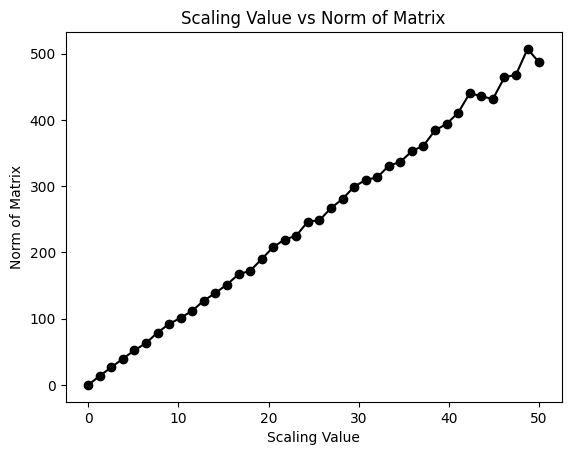

In [12]:
plt.plot(scaling_values,np.mean(norm_matrix,axis=1), "ko-")
plt.xlabel("Scaling Value")
plt.ylabel("Norm of Matrix")
plt.title("Scaling Value vs Norm of Matrix")


What we are seeing from this problem is that the norm of a matrix is related to the scale of the numerical values in the matrix. This makes sense given the norm of a matrix is the Euclidean distance from the origin. So if we had values in the matrix that are larger then the norm (distance) would be larger.

# Exercise 6-2
- Write an algorithm that finds a scalar that brings the Frobenius distance between two matrices to 1.
- Write a python function that takes 2 matrices of the same size and returns the Frobenius distance between them
- Then create 2 NxN random matrices.
- Create a variable `s = 1` that scalar multiplies both matrices
- As long as the distance remains above 1, set the scalar to be 0.9 itself and recompute the distance between the scaled matrices.

In [13]:
def frob_dist(A: np.ndarray, B: np.ndarray) -> np.float64:
    return np.linalg.norm(A - B)

In [14]:
size = 7
X, Y = np.random.randn(size, size), np.random.randn(size, size)
X, Y

(array([[-0.62715697, -0.55892584, -0.18578938,  0.63935626, -0.34563002,
          0.20401803,  1.05735874],
        [-1.09395795,  1.62014931,  0.19687893, -0.94167214,  0.38646667,
          1.06007314, -1.61507357],
        [-1.67732074, -0.90500983, -0.76378715,  1.48863913,  1.15275122,
          1.73999111,  0.69826999],
        [-0.31770689, -0.02172168, -0.32380266, -2.60121813, -1.37796038,
         -1.40907428, -1.08598767],
        [-0.01382389,  0.82014989,  0.05320637,  1.3200099 , -0.49683476,
          0.91374473,  0.2544803 ],
        [-0.50354658, -0.45547284, -0.1835723 ,  0.14389896,  0.97202677,
          0.12767395, -0.69195301],
        [-0.09467038, -1.43612777,  0.61162884,  0.11334699,  0.28727517,
          0.95788275,  0.01468902]]),
 array([[ 0.13951576,  0.24828728, -1.37885249,  0.11626659, -0.07414694,
          0.18775867,  0.57468121],
        [ 1.54176164, -0.57446787,  0.66971865, -1.97675423,  0.30994291,
          1.4667958 , -0.9839218 ],
        

In [15]:
frob_dist(X, Y)

np.float64(8.428074261078628)

In [20]:
scalar = 1
count = 0
while (distance := frob_dist(X*scalar, Y*scalar)) > 1:
    scalar *= 0.9
    count += 1

In [21]:
distance, count

(np.float64(0.9221913659725421), 21)

# Exercise 6-3
- Demonstrate that the trace method and the Euclidean formula produce the same result
- Does the trace formular work only for $A^TA$ or is it the same for $AA^T$?
    - The trace is just the sum of the diagonals. In a transpose operation the diagonals would stay the same and so those are equivalent

In [22]:
trace_matrix = np.random.randn(size, size)
trace_matrix

array([[-1.760203  ,  0.5412685 ,  0.10876382, -1.84848227, -1.43552519,
         0.76377966,  0.50084183],
       [-0.25164082,  0.28157514, -0.03938064,  0.49908402, -0.77506521,
        -0.78946504, -1.51692729],
       [-0.69706052,  0.44497867, -0.28027411,  0.22666937, -0.94116848,
        -0.08681267, -0.9189405 ],
       [ 1.26515917, -0.96816542,  1.33620034, -0.0512812 ,  1.33407637,
        -0.65188503, -1.17905229],
       [ 1.86510851,  0.89157373, -1.08160578, -0.23176906,  1.39982323,
         0.37224791,  1.68287655],
       [-1.33102303,  0.43726129, -0.18279339,  0.34583025,  0.48685965,
         0.68745884,  0.19695325],
       [-2.43883526, -1.08142732,  1.69940817,  1.61916596,  0.20367882,
        -0.32567353,  0.96352099]])

In [23]:
trace_norm = np.linalg.norm(trace_matrix)
trace_based_norm = np.sqrt(np.trace(trace_matrix.T @ trace_matrix))
trace_norm, trace_based_norm

(np.float64(7.148446831410565), np.float64(7.148446831410565))

In [24]:
np.sqrt(np.trace(trace_matrix @ trace_matrix.T))

np.float64(7.148446831410565)